# 🧾 OCR on SROIE Dataset using PaddleOCR

**SROIE** (Scanned Receipts OCR and Information Extraction)  dataset  for receipt OCR and key information extraction.

## 📌 Project Goals
1. **Text Detection** — Locate text bounding boxes on receipt images
2. **Text Recognition** — Read the text inside each bounding box
3. **Evaluation** — Measure quality using Precision, Recall, F1 and CER/WER
4. **Key Information Extraction** — Extract Company, Date, Address, Total

---
## Step 1 — Install Dependencies

In [2]:
!pip install "paddlepaddle==2.6.2" -q
!pip install "paddleocr==2.9.1" -q
!pip install jiwer shapely tqdm matplotlib pandas Pillow opencv-python-headless -q
print('✅ Installed PaddleOCR + PaddlePaddle ')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 13.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.7/544.7 kB 11.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.9/161.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 82.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 26.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 29.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 15.

---
## Step 2 — Imports 

In [4]:
import subprocess
subprocess.run([
    'pip', 'install', '--force-reinstall', '--no-cache-dir', '--quiet',
    'numpy==1.26.4',
    'pandas==2.2.2',
], check=True)
print("Done — now restart the kernel before importing anything")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 218.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 195.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 318.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 312.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 273.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

Done — now restart the kernel before importing anything


In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import os, glob, json, re, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.notebook import tqdm #progress bars
from pathlib import Path

warnings.filterwarnings('ignore')


DATASET_ROOT = Path('/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019')

TRAIN_IMG_DIR = DATASET_ROOT / 'train' / 'img'
TRAIN_BOX_DIR = DATASET_ROOT / 'train' / 'box'
TEST_IMG_DIR  = DATASET_ROOT / 'test'  / 'img'
TEST_BOX_DIR  = DATASET_ROOT / 'test'  / 'box'

OUTPUT_DIR = Path('/kaggle/working/results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


train_imgs = sorted(TRAIN_IMG_DIR.glob('*.jpg'))
test_imgs  = sorted(TEST_IMG_DIR.glob('*.jpg'))
print(f'Training images : {len(train_imgs)}')
print(f'Test images     : {len(test_imgs)}')

Training images : 626
Test images     : 347


---
## Step 3 — Explore the Dataset

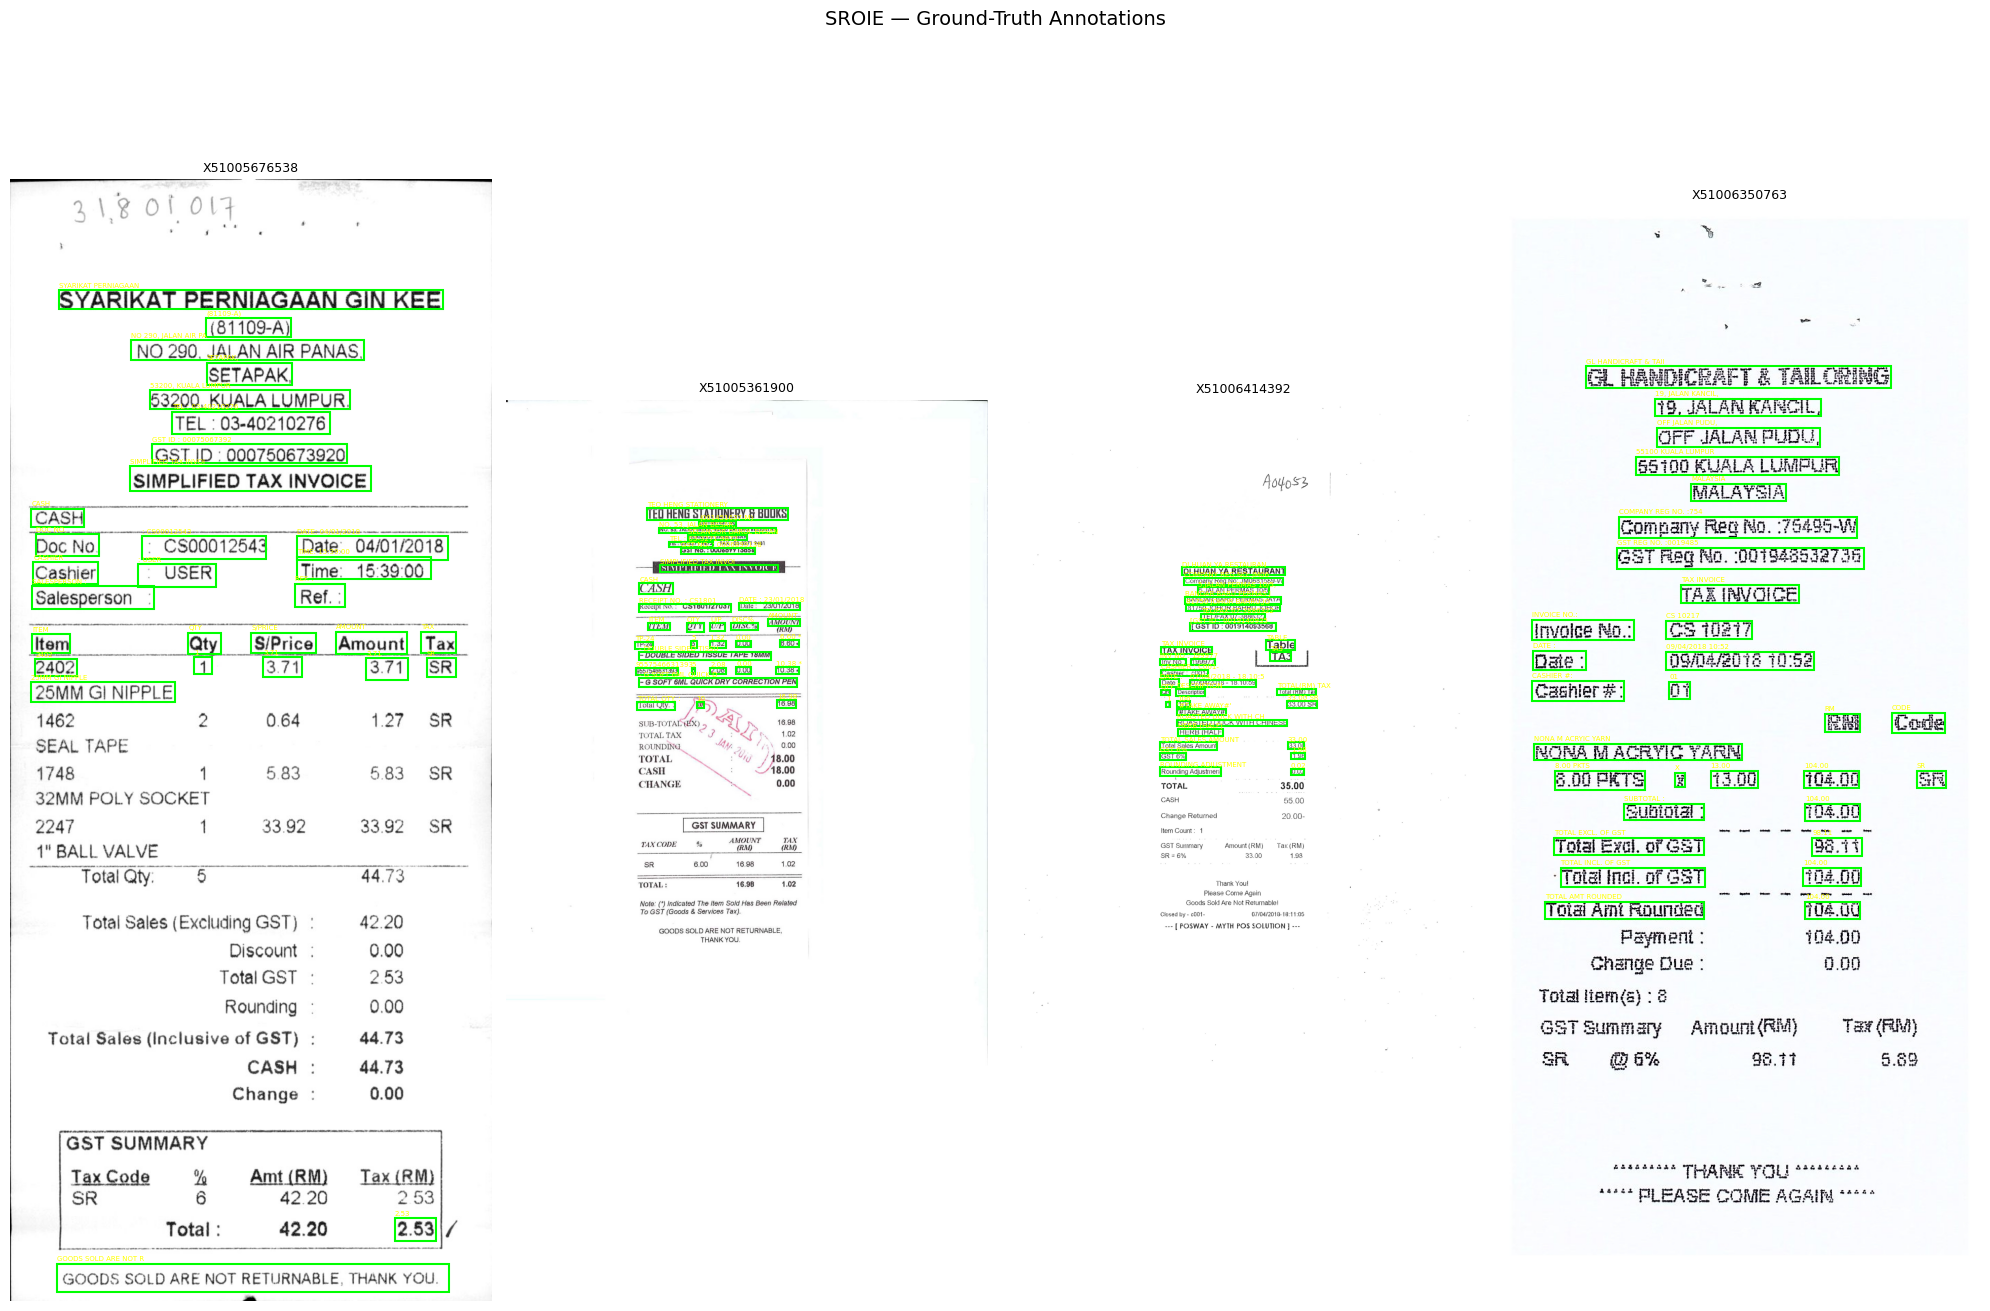

Sample visualization saved.


In [2]:
def parse_annotation(ann_path: Path): #reads box as annotation coordinates +text
    records = [] 
    with open(ann_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip() #clean for spaces endlines etc..
            if not line:
                continue
            parts = line.split(',')
            if len(parts) < 9:
                continue
            coords = list(map(int, parts[:8]))
            text   = ','.join(parts[8:]).strip() #some data contains comma
            records.append({'box': coords, 'text': text})
    return records


def visualize_annotations(img_path: Path, ann_path: Path, max_boxes=30, ax=None):
    img = np.array(Image.open(img_path).convert('RGB'))
    records = parse_annotation(ann_path)
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 12))
    ax.imshow(img)
    for r in records[:max_boxes]:
        xs = r['box'][0::2];  ys = r['box'][1::2]
        poly = plt.Polygon(list(zip(xs, ys)), fill=False,
                           edgecolor='lime', linewidth=1.5)
        ax.add_patch(poly)
        ax.text(xs[0], ys[0]-4, r['text'][:20], color='yellow',
                fontsize=5, va='bottom')
    ax.axis('off')
    ax.set_title(img_path.stem, fontsize=9)



import random
random.seed(42)
samples = random.sample(train_imgs, 4)

fig, axes = plt.subplots(1, 4, figsize=(20, 14))
for img_path, ax in zip(samples, axes):
    ann_path = TRAIN_BOX_DIR / (img_path.stem + '.txt')
    visualize_annotations(img_path, ann_path, ax=ax)

plt.suptitle('SROIE — Ground-Truth Annotations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_annotations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample visualization saved.')

Total training text instances : 33626
Avg boxes per image           : 53.7
Max boxes in one image        : 153
Unique characters             : 72


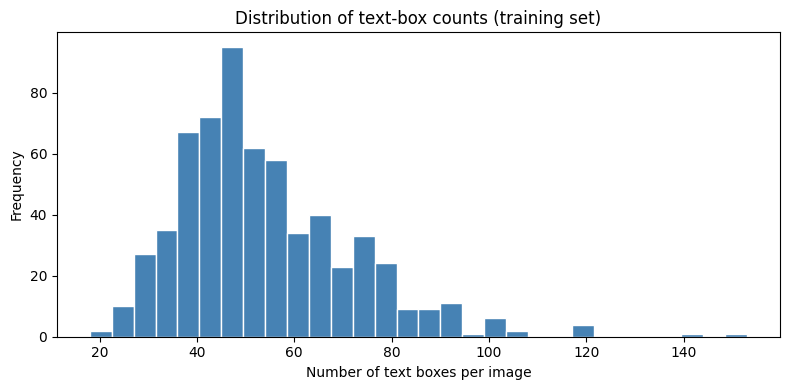

In [3]:

all_texts, box_counts = [], []
for img_path in train_imgs:
    ann_path = TRAIN_BOX_DIR / (img_path.stem + '.txt')
    if ann_path.exists():
        records = parse_annotation(ann_path)
        box_counts.append(len(records))
        all_texts.extend([r['text'] for r in records]) #Adds items individually:

print(f'Total training text instances : {len(all_texts)}')
print(f'Avg boxes per image           : {np.mean(box_counts):.1f}')
print(f'Max boxes in one image        : {max(box_counts)}')
print(f'Unique characters             : {len(set("".join(all_texts)))}')


fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(box_counts, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of text boxes per image')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of text-box counts (training set)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'box_count_dist.png', dpi=120)
plt.show()

---
## Step 4 — Initialize PaddleOCR



In [4]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    use_angle_cls=True,
    lang='en',
    use_gpu=True,
    show_log=False
)
print('✅ PaddleOCR ready')

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:15<00:00, 246.57it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:19<00:00, 512.92it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:19<00:00, 108.61it/s]


✅ PaddleOCR ready


---
## Step 5 — Run OCR on a Single Image 

Detected 43 text instances in X00016469612.jpg

Top 5 detections:
  [1.000] tan woon yann
  [0.920] BOOK TA KTAMANDAYA SDN BHD
  [0.979] 789417-W
  [0.915] NO.555,57&59JALANSAGU18
  [0.958] TAMAN DAYA


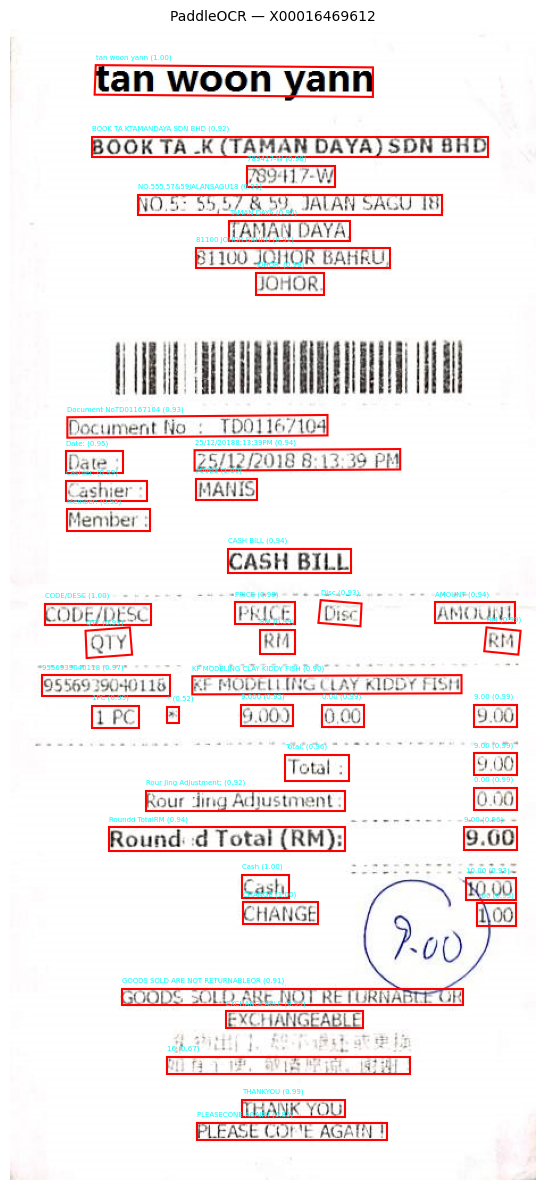

In [5]:
def run_ocr(img_path):
    result = ocr.ocr(str(img_path), cls=True) #outer list images inner list texts
    parsed = [] #clean OCR results
    if not result:
        return parsed
    for page in result:          
        if not page:
            continue
        for line in page:
            box  = line[0]        
            text = line[1][0]
            conf = float(line[1][1])
            parsed.append({'box': box, 'text': text, 'confidence': conf})
    return parsed


def visualize_ocr_result(img_path, ocr_results, title='PaddleOCR Result'):
    img = np.array(Image.open(img_path).convert('RGB'))
    fig, ax = plt.subplots(1, 1, figsize=(8, 12))
    ax.imshow(img)
    for r in ocr_results:
        box = np.array(r['box'], dtype=np.int32)
        poly = plt.Polygon(box, fill=False, edgecolor='red', linewidth=1.5)
        ax.add_patch(poly)
        ax.text(box[0][0], box[0][1]-4,
                f"{r['text']} ({r['confidence']:.2f})",
                color='cyan', fontsize=5, va='bottom')
    ax.axis('off')
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()


# Test on first training image
test_img = train_imgs[0]
results  = run_ocr(test_img)
print(f'Detected {len(results)} text instances in {test_img.name}')
print('\nTop 5 detections:')
for r in results[:5]:
    print(f"  [{r['confidence']:.3f}] {r['text']}")

visualize_ocr_result(test_img, results, title=f'PaddleOCR — {test_img.stem}')

---
## Step 6 — Evaluation Metrics

### Metrics used
| Metric | What it measures |
|--------|------------------|
| **IoU** | Overlap between predicted & GT bounding boxes |
| **Precision / Recall / F1** | Detection quality (IoU ≥ 0.5 threshold) |
| **CER** | Character Error Rate (recognition quality) |
| **WER** | Word Error Rate |


In [6]:
from shapely.geometry import Polygon as ShapelyPolygon
from jiwer import cer, wer



def box_to_polygon(box):
    #convert into geometric shapes handle 2 formats
    if isinstance(box[0], (list, tuple)):   
        pts = box
    else:                                    
        pts = [(box[i], box[i+1]) for i in range(0, 8, 2)]
    poly = ShapelyPolygon(pts)
    return poly if poly.is_valid else poly.buffer(0)


def polygon_iou(box_a, box_b):
    pa, pb = box_to_polygon(box_a), box_to_polygon(box_b)
    inter  = pa.intersection(pb).area
    union  = pa.union(pb).area
    return inter / union if union > 0 else 0.0


#how many boxes are corectly detected
def evaluate_detection(pred_boxes, gt_boxes, iou_thresh=0.5):

    matched_pred = set()
    tp = 0
    for gt in gt_boxes:
        best_iou, best_idx = 0, -1
        for i, pred in enumerate(pred_boxes):
            if i in matched_pred:
                continue
            iou = polygon_iou(pred, gt)
            if iou > best_iou:
                best_iou, best_idx = iou, i
        if best_iou >= iou_thresh:
            tp += 1
            matched_pred.add(best_idx)
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes)   - tp
    return tp, fp, fn


def prf(tp, fp, fn):
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0.0
    return prec, rec, f1


print('✅ Metric helpers defined.')

✅ Metric helpers defined.


---
## Step 7 — Full Evaluation on the Test Set



In [7]:
MAX_IMAGES = len(test_imgs)   

total_tp = total_fp = total_fn = 0
all_pred_texts, all_gt_texts   = [], []
per_image_results = []

for img_path in tqdm(test_imgs[:MAX_IMAGES], desc='Evaluating'):
    ann_path = TEST_BOX_DIR / (img_path.stem + '.txt')
    if not ann_path.exists():
        continue

    gt_records  = parse_annotation(ann_path)
    gt_boxes    = [r['box'] for r in gt_records]
    gt_texts    = [r['text'] for r in gt_records]

    pred_records = run_ocr(img_path)
    pred_boxes   = [r['box'] for r in pred_records]
    pred_texts   = [r['text'] for r in pred_records]

    
    tp, fp, fn = evaluate_detection(pred_boxes, gt_boxes)
    total_tp += tp
    total_fp += fp
    total_fn += fn

   
    if gt_texts:
        all_gt_texts.append(' '.join(gt_texts))
        all_pred_texts.append(' '.join(pred_texts) if pred_texts else '')

    prec, rec, f1 = prf(tp, fp, fn)
    per_image_results.append({
        'image'     : img_path.stem,
        'gt_boxes'  : len(gt_boxes),
        'pred_boxes': len(pred_boxes),
        'tp': tp, 'fp': fp, 'fn': fn,
        'precision' : prec,
        'recall'    : rec,
        'f1'        : f1
    })


overall_prec, overall_rec, overall_f1 = prf(total_tp, total_fp, total_fn)

overall_cer = cer(all_gt_texts, all_pred_texts) if all_gt_texts else float('nan')
overall_wer = wer(all_gt_texts, all_pred_texts) if all_gt_texts else float('nan')

print('\n' + '='*55)
print('       EVALUATION RESULTS (PaddleOCR on SROIE Test)')
print('='*55)
print(f'  Images evaluated  : {len(per_image_results)}')
print(f'  Detection Precision: {overall_prec:.4f}')
print(f'  Detection Recall   : {overall_rec:.4f}')
print(f'  Detection F1       : {overall_f1:.4f}')
print(f'  Character Error Rate (CER): {overall_cer:.4f}')
print(f'  Word Error Rate    (WER)  : {overall_wer:.4f}')
print('='*55)

Evaluating:   0%|          | 0/347 [00:00<?, ?it/s]


       EVALUATION RESULTS (PaddleOCR on SROIE Test)
  Images evaluated  : 347
  Detection Precision: 0.9430
  Detection Recall   : 0.8962
  Detection F1       : 0.9190
  Character Error Rate (CER): 0.3843
  Word Error Rate    (WER)  : 0.6792


---
## Step 8 — Save Predictions & Per-Image Report

In [8]:

df = pd.DataFrame(per_image_results)
df.to_csv(OUTPUT_DIR / 'per_image_results.csv', index=False)
print('Saved per_image_results.csv')
display(df.describe().round(4))


summary = {
    'images_evaluated' : len(per_image_results),
    'detection_precision': round(overall_prec, 4),
    'detection_recall'   : round(overall_rec, 4),
    'detection_f1'       : round(overall_f1, 4),
    'cer'                : round(overall_cer, 4),
    'wer'                : round(overall_wer, 4)
}
with open(OUTPUT_DIR / 'summary.json', 'w') as fp:
    json.dump(summary, fp, indent=2)
print('Saved summary.json')
print(json.dumps(summary, indent=2))

Saved per_image_results.csv


,gt_boxes,pred_boxes,tp,fp,fn,precision,recall,f1
count,347.0000,347.0000,347.0000,347.0000,347.0000,347.0000,347.0000,347.0000
mean,53.9049,51.2277,48.3084,2.9193,5.5965,0.9456,0.9029,0.9229
std,17.4152,16.1886,14.9278,3.1695,5.6178,0.0499,0.0799,0.0625
min,23.0000,23.0000,19.0000,0.0000,0.0000,0.6786,0.5758,0.6230
25%,42.0000,39.5000,38.0000,1.0000,2.0000,0.9242,0.8606,0.8916
50%,51.0000,47.0000,45.0000,2.0000,4.0000,0.9559,0.9178,0.9362
75%,64.0000,61.5000,58.0000,4.0000,8.0000,0.9787,0.9628,0.9688
max,121.0000,106.0000,97.0000,32.0000,47.0000,1.0000,1.0000,1.0000


Saved summary.json
{
  "images_evaluated": 347,
  "detection_precision": 0.943,
  "detection_recall": 0.8962,
  "detection_f1": 0.919,
  "cer": 0.3843,
  "wer": 0.6792
}


In [10]:

PRED_TXT_DIR = OUTPUT_DIR / 'pred_texts'
PRED_TXT_DIR.mkdir(exist_ok=True)

for img_path in tqdm(test_imgs[:MAX_IMAGES], desc='Saving predictions'):
    preds = run_ocr(img_path)
    out_path = PRED_TXT_DIR / (img_path.stem + '.txt')
    with open(out_path, 'w') as f:
        for r in preds:
            
            coords = ','.join([f'{int(p[0])},{int(p[1])}' for p in r['box']])
            f.write(f"{coords},{r['text']},{r['confidence']:.4f}\n")

print(f'✅ Prediction files saved to {PRED_TXT_DIR}')

Saving predictions:   0%|          | 0/347 [00:00<?, ?it/s]

✅ Prediction files saved to /kaggle/working/results/pred_texts


---
## Step 9 — Visualise Results

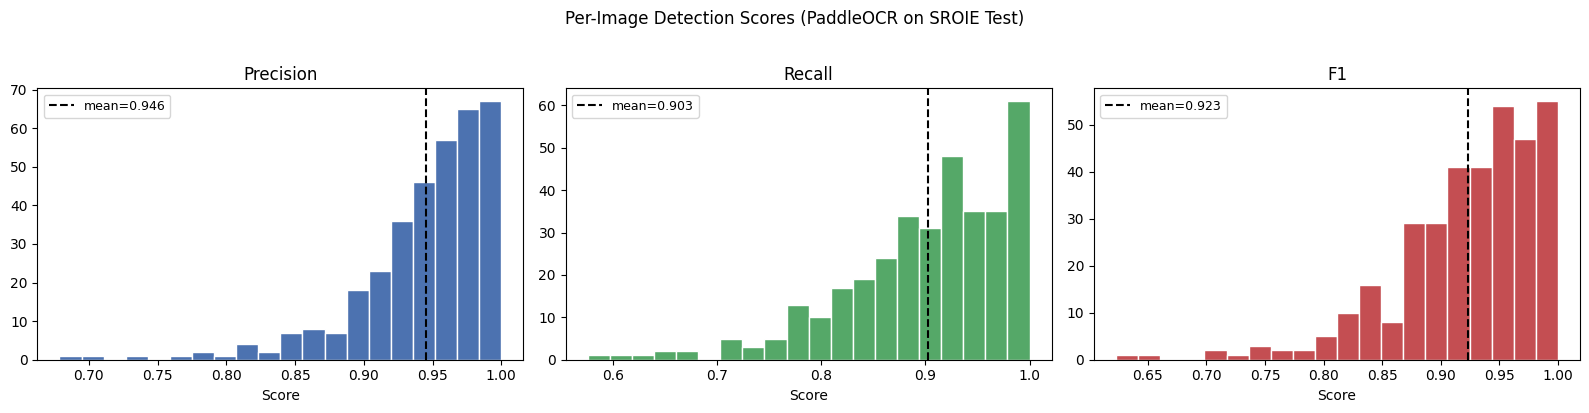

In [11]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes,
                           ['precision', 'recall', 'f1'],
                           ['#4C72B0', '#55A868', '#C44E52']):
    ax.hist(df[col], bins=20, color=color, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'mean={df[col].mean():.3f}')
    ax.set_title(col.title())
    ax.set_xlabel('Score')
    ax.legend(fontsize=9)

plt.suptitle('Per-Image Detection Scores (PaddleOCR on SROIE Test)', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'score_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

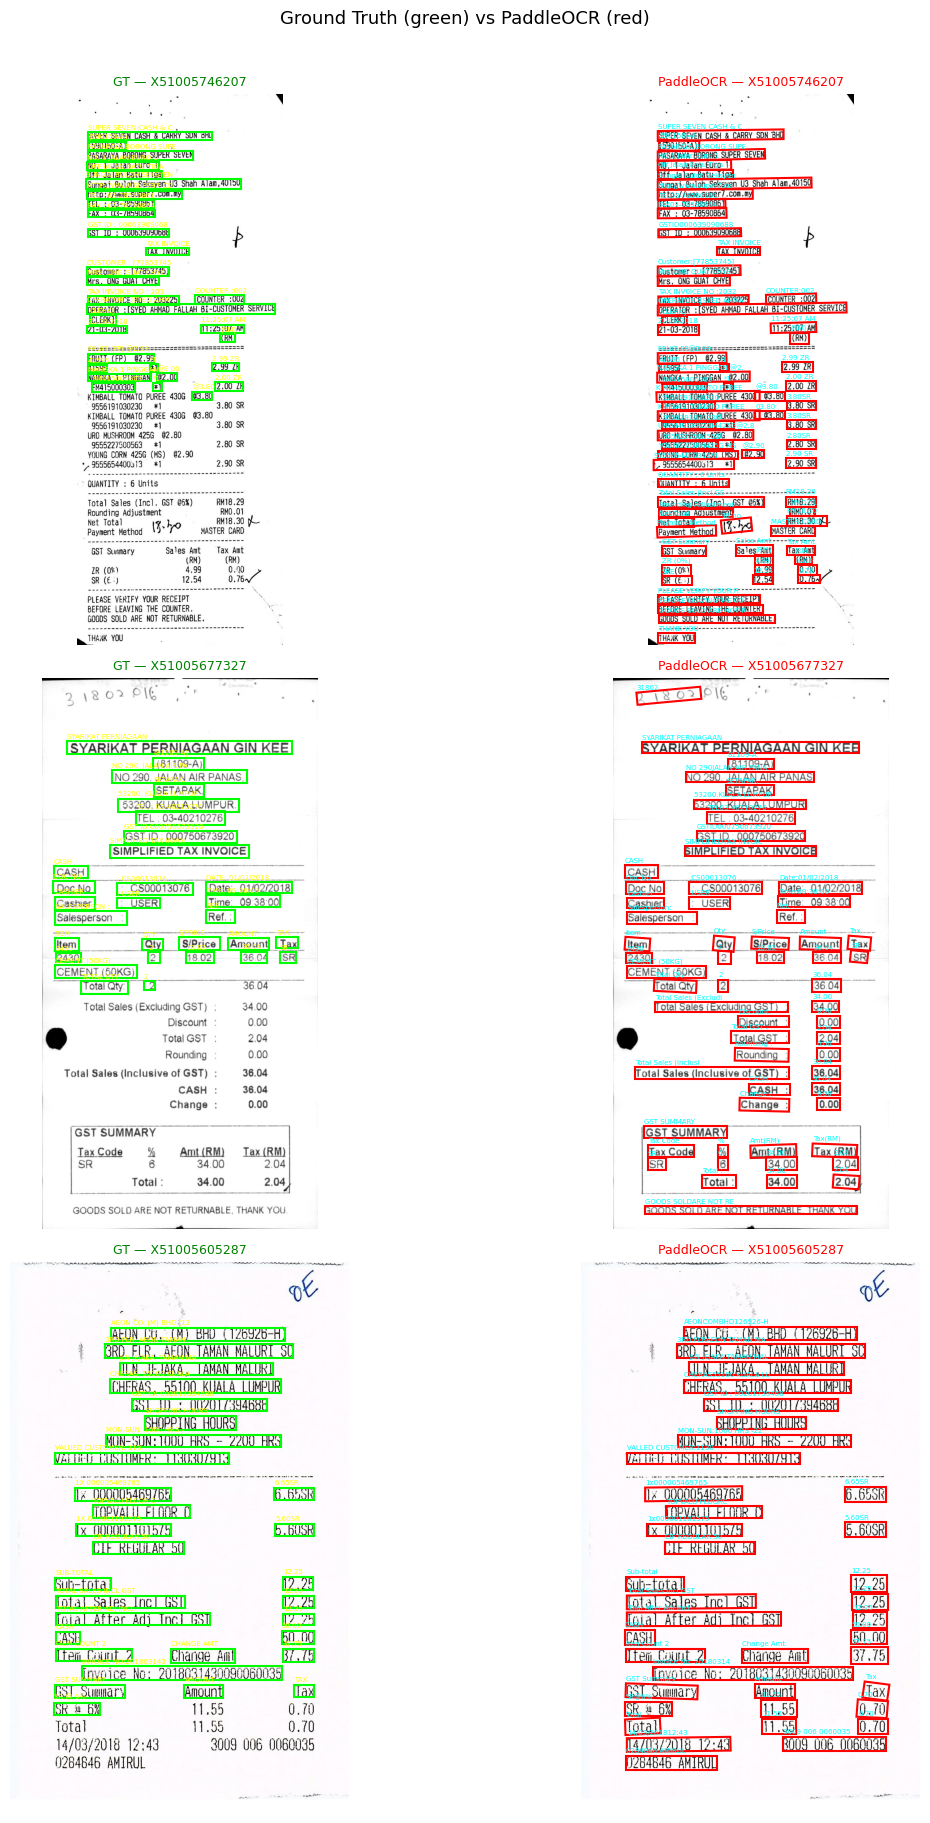

In [12]:

samples = random.sample(test_imgs[:MAX_IMAGES], min(3, MAX_IMAGES))

fig, axes = plt.subplots(len(samples), 2, figsize=(14, 6*len(samples)))
if len(samples) == 1:
    axes = [axes]

for img_path, (ax_gt, ax_pred) in zip(samples, axes):
    ann_path = TEST_BOX_DIR / (img_path.stem + '.txt')

    
    visualize_annotations(img_path, ann_path, ax=ax_gt)
    ax_gt.set_title(f'GT — {img_path.stem}', color='green', fontsize=9)

    
    preds = run_ocr(img_path)
    img   = np.array(Image.open(img_path).convert('RGB'))
    ax_pred.imshow(img)
    for r in preds:
        box  = np.array(r['box'], dtype=np.int32)
        poly = plt.Polygon(box, fill=False, edgecolor='red', linewidth=1.5)
        ax_pred.add_patch(poly)
        ax_pred.text(box[0][0], box[0][1]-4,
                     r['text'][:20], color='cyan', fontsize=5, va='bottom')
    ax_pred.axis('off')
    ax_pred.set_title(f'PaddleOCR — {img_path.stem}', color='red', fontsize=9)

plt.suptitle('Ground Truth (green) vs PaddleOCR (red)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gt_vs_pred.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Step 10 —  Key Information Extraction

In [13]:
import re


def extract_key_info(ocr_results):
    
    texts = [r['text'].strip() for r in ocr_results]
    full  = ' '.join(texts)

    
    date_pat = re.compile(
        r'\b(\d{1,2}[\-/]\d{1,2}[\-/]\d{2,4}'
        r'|\d{1,2}\s+(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\s+\d{2,4})\b',
        re.IGNORECASE
    )
    dates = date_pat.findall(full)

    
    total_pat = re.compile(r'total[\s:$]*(\d+[\.,]\d{2})', re.IGNORECASE)
    totals = total_pat.findall(full)

    
    company = texts[0] if texts else ''

    
    addr_kw  = re.compile(r'\b(jalan|jln|lorong|no\.|lot|block|taman|street|road|avenue|ave|blvd)\b', re.I)
    address  = next((t for t in texts if addr_kw.search(t)), '')

    return {
        'company': company,
        'date'   : dates[0] if dates else '',
        'address': address,
        'total'  : totals[0] if totals else ''
    }


# Demo on first 5 test images
print('Key Information Extraction Demo\n' + '-'*45)
for img_path in test_imgs[:5]:
    preds = run_ocr(img_path)
    info  = extract_key_info(preds)
    print(f'\n📄 {img_path.stem}')
    for k, v in info.items():
        print(f'  {k:10}: {v}')

Key Information Extraction Demo
---------------------------------------------

📄 X00016469670
  company   : tan chay yee
  date      : 
  address   : 
  total     : 193.00

📄 X00016469671
  company   : tan chay yee
  date      : 
  address   : 
  total     : 170.00

📄 X51005200931
  company   : PERNIAGAAN ZHENG HU!
  date      : 09/02/2018
  address   : NO.59 JALAN PERMAS 9/5
  total     : 411.50

📄 X51005230605
  company   : PETRON BKT LANJAN SB
  date      : 01/02/2018
  address   : Store No.129077
  total     : 

📄 X51005230616
  company   : Q0543
  date      : 19-18/01
  address   : No.3,JalanSS21/39,47400 Peta1ing Jaya
  total     : 


In [14]:
# Save KIE results to CSV
kie_rows = []
for img_path in tqdm(test_imgs[:MAX_IMAGES], desc='KIE extraction'):
    preds = run_ocr(img_path)
    info  = extract_key_info(preds)
    info['image'] = img_path.stem
    kie_rows.append(info)

df_kie = pd.DataFrame(kie_rows)[['image', 'company', 'date', 'address', 'total']]
df_kie.to_csv(OUTPUT_DIR / 'key_info_extraction.csv', index=False)
print('✅ Saved key_info_extraction.csv')
display(df_kie.head(10))

KIE extraction:   0%|          | 0/347 [00:00<?, ?it/s]

✅ Saved key_info_extraction.csv


,image,company,date,address,total
0,X00016469670,tan chay yee,,,193.00
1,X00016469671,tan chay yee,,,170.00
2,X51005200931,PERNIAGAAN ZHENG HU!,09/02/2018,NO.59 JALAN PERMAS 9/5,411.50
3,X51005230605,PETRON BKT LANJAN SB,01/02/2018,Store No.129077,
4,X51005230616,Q0543,19-18/01,"No.3,JalanSS21/39,47400 Peta1ing Jaya",
5,X51005230621,SIN LIANHAP SON BHD,05/02/2018,"LOT13,JALAN",7.30
6,X51005230648,CROSS CHANNEL NETWORK SDN.BHD.,,No.BTG-052332,
7,X51005230657,CROSS CHANNEL NEIWORK SDN.BHD,31/12/2017,"47,JALAN MERANTI1SEK.3,",7.50
8,X51005230659,SWCENTERPRISE SDNBHD,08/01/2018,"NO.5-7Jalan Mahagoni 7/1,",
9,X51005268275,LIGHTROOM GALLERY SDN BHD,20/11/2017,"No:28,JALAN ASTANA 1C,",


---
## Step 11 — Final Summary

In [9]:
print('\n' + '='*60)
print('  SROIE × PaddleOCR  —  Final Results Summary')
print('='*60)
print(f"  Dataset            : SROIE 2019")
print(f"  Model              : PaddleOCR (EN, angle-cls, CPU)")
print(f"  Images evaluated   : {len(per_image_results)}")
print()
print(f"  ── Text Detection (IoU ≥ 0.5) ─────────────")
print(f"  Precision          : {overall_prec:.4f}")
print(f"  Recall             : {overall_rec:.4f}")
print(f"  F1                 : {overall_f1:.4f}")
print()
print(f"  ── Text Recognition ────────────────────────")
print(f"  CER (↓ better)     : {overall_cer:.4f}")
print(f"  WER (↓ better)     : {overall_wer:.4f}")



  SROIE × PaddleOCR  —  Final Results Summary
  Dataset            : SROIE 2019
  Model              : PaddleOCR (EN, angle-cls, CPU)
  Images evaluated   : 347

  ── Text Detection (IoU ≥ 0.5) ─────────────
  Precision          : 0.9430
  Recall             : 0.8962
  F1                 : 0.9190

  ── Text Recognition ────────────────────────
  CER (↓ better)     : 0.3843
  WER (↓ better)     : 0.6792


---
## 📚 Next Steps & Improvements

| Idea | Impact |
|------|--------|
| Enable GPU (`use_gpu=True`) | 5–10× faster inference |
| Preprocessing (deskewing, denoising) | Better detection on skewed receipts |
| Fine-tune on SROIE training set | Higher accuracy |
| BERT-based NER for KIE | More robust entity extraction |
| Ensemble multiple OCR engines | Higher recall |
| Post-process with dictionary matching | Lower CER |

